# IoT Auth Simulator — Feature Table Analysis (ML readiness)

This notebook analyzes the **session-level feature table**
(`iot_auth_dataset_features.csv`, one row per authentication session), as
opposed to the event-level consistency notebook
(`iot_auth_dataset_quality_analysis.ipynb`).

The goal is to assess whether the generated features are ready for supervised
learning, and to surface issues that affect model success:

1. Overview, schema & column taxonomy
2. Target analysis (`is_anomaly`, `attack_type`, `attack_phase`, `severity`) and class balance
3. Missingness
4. Constant / near-constant / duplicate columns and rows
5. Numeric feature distributions, split by class
6. Data-quality flags (e.g. negative durations)
7. **Label-leakage diagnostics** — single-feature separability vs the target
8. Correlation & mutual information with the target
9. Per-attack-type feature signatures
10. Recommended feature sets and next steps

All figures and summary tables are written to `feature_analysis_outputs/`.

## 0. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Locate the feature CSV regardless of where the notebook is launched from.
CANDIDATES = [
    Path("iot_auth_dataset_features.csv"),
    Path("simulator/data/output/iot_auth_dataset_features.csv"),
    Path(r"C:/Users/lamia/Desktop/simulator_bis/PFE_simulator/IoT_auth_simulator/simulator/data/output/iot_auth_dataset_features.csv"),
]
CSV_PATH = next((p for p in CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError("Could not find iot_auth_dataset_features.csv")

OUTPUT_DIR = Path("feature_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Loading:", CSV_PATH.resolve())

Loading: C:\Users\lamia\Desktop\simulator_bis\PFE_simulator\IoT_auth_simulator\simulator\data\output\iot_auth_dataset_features.csv


## 1. Overview

In [2]:
df = pd.read_csv(CSV_PATH)
print(f"Rows (sessions): {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]:,}")
print(f"Memory         : {df.memory_usage(deep=True).sum()/1e6:.2f} MB")
display(df.head(3))

dtypes = df.dtypes.astype(str).value_counts().to_frame("n_columns")
display(Markdown("### Column dtypes"))
display(dtypes)

Rows (sessions): 1,100
Columns        : 103
Memory         : 1.18 MB


,scenario_id,session_id,device_id,gateway_id,claimed_device_id,source_ip,registered_device,source_connection_count,battery_level,tcp_flags,connection_duration,tcp_rtt,packet_rate,inter_arrival_time,frame_length,tcp_segment_len,pairing_result,pairing_latency_ms,mqtt_msg_type,connect_flags,clean_session,username_present,password_length,keep_alive,mqtt_version,connack_code,auth_result,auth_latency_ms,failed_auth_count,requested_topic,topic_length,operation,authorization_result,topic_scope_violation,retain_flag,message_id,duplicate_flag,payload_length,payload_hash,qos_level,message_rate,byte_rate,trust_score,re_auth_required,session_present,source_ip_change,replay_window_violation,s1_latency_ms,s2_latency_ms,s3_latency_ms,s4_latency_ms,s5_latency_ms,s6_latency_ms,session_duration_s,mean_delay_s,max_delay_s,min_delay_s,n_events,n_registration_request,n_registration_confirmed,n_authentication_request,n_challenge_sent,n_nonce_received,n_response_sent,n_authentication_success,n_authentication_failure,n_token_issued,n_token_presented,n_token_validated,n_token_rejected,n_renewal_request,n_token_expired,n_session_opened,n_session_closed,n_access_request,n_access_granted,n_access_denied,n_retry,n_timeout,n_disconnect,visited_states,reached_session_open,reached_access_granted,reached_authenticated,n_failures,n_retries,failure_rate,n_token_reuses,n_nonce_reuses,identity_mismatch,n_state_jumps,is_anomaly,attack_type,attack_phase,severity,token_age_at_replay,nonce_age_at_reuse,timestamp_delta_s,duplicate_session_count,identity_claim_mismatch,token_device_mismatch,unauthorized_access_attempt,steps_before_access
0,c3acda0b-6554-412c-8723-6e23b70aa127,ddfb0860-5c31-463c-92d0-48296de8ee85,e05442ad-ede5-4df3-b61a-d0423ab7eac5,7a9ca8b9,e05442ad-ede5-4df3-b61a-d0423ab7eac5,10.0.1.60,1,9,27.7,"SYN,ACK",39269.39,25.74,3.048,328.12,76,438,1,32.90,PUBLISH,0,0,0,0,60,5,success,1,44.45,0,iot/e05442ad/telemetry,22,publish,1,0,0,48646,0,264,15fb1dc265e0b4d43be05af1a915ead67aca3a169c33da...,2,1.123,296.48,0.80,0,1,0,0,0.0,32.90,44.45,128.73,43.07,0.0,39.2694,2.8050,35.1741,0.0329,14,1,1,1,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,0,0,0,0,11,1,1,1,1,0,0.0714,5,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0
1,05069002-a367-42c9-b1c9-2a5d1c722983,30296c76-9ef3-4e12-9843-c04d906abd23,8d1b6dad-9596-4fae-97f7-efdabfa437ed,9e4c03ac,8d1b6dad-9596-4fae-97f7-efdabfa437ed,10.0.1.187,1,8,98.5,"SYN,ACK",42087.18,16.64,5.486,182.30,134,202,1,34.64,UNSUBSCRIBE,0,0,0,0,60,5,success,1,111.83,1,iot/8d1b6dad/telemetry,22,pub_sub,1,0,0,4400,0,0,NaN,0,0.608,173.87,0.65,0,1,0,0,0.0,34.64,111.83,91.58,52.81,0.0,42.0872,2.2151,35.6215,0.0346,19,1,1,1,2,2,2,1,1,1,1,1,0,0,0,1,1,1,1,0,1,0,0,12,1,1,1,1,1,0.0526,5,4,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0
2,25cc1733-18fb-4185-a837-3516cafde0b9,dc5b9433-065d-4de3-ad3f-8210d9293486,0ca3b955-b3e3-493a-9b9f-f6d360720a4a,47ffa15d,victim-2aea94e2,10.0.1.24,0,4,20.5,SYN,159.95,1.00,436.388,2.29,137,435,0,11.77,PUBLISH,0,0,0,0,10,5,pending,0,0.00,0,iot/0ca3b955/telemetry,22,publish,0,0,0,50081,0,3392,6c42e16dc30c2be16c1d2dd1b6bb737de9933306e33f0e...,1,255.768,867564.51,0.80,0,0,1,0,0.0,11.77,0.00,0.00,0.00,0.0,0.1599,0.0228,0.0474,0.0118,7,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,5,0,0,0,1,0,0.1429,0,2,1,1,1,impersonation,session_opened,high,0.0,0.0,0.0,0,1,0,0,0


### Column dtypes

,n_columns
int64,64
float64,24
str,15


## 2. Column taxonomy

The 103 columns fall into logical groups. Identifiers carry no predictive
signal and must be dropped before training; labels are the supervision target;
the rest are candidate features split by simulation phase.

In [3]:
IDENTIFIERS = ["scenario_id", "session_id", "device_id", "gateway_id",
               "claimed_device_id", "source_ip", "message_id", "payload_hash"]
LABELS      = ["is_anomaly", "attack_type", "attack_phase", "severity"]

# Detector-style features that may directly encode an attack mechanism
# (candidates for leakage — tested empirically in section 7).
SUSPECTED_LEAKAGE = [
    "replay_window_violation", "topic_scope_violation",
    "token_age_at_replay", "nonce_age_at_reuse", "timestamp_delta_s",
    "duplicate_session_count", "identity_claim_mismatch",
    "token_device_mismatch", "unauthorized_access_attempt",
]

EVENT_COUNTS = [c for c in df.columns if c.startswith("n_")]
present = lambda cols: [c for c in cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in IDENTIFIERS + LABELS]
numeric_cols = df[feature_cols].select_dtypes(include="number").columns.tolist()
categ_cols   = [c for c in feature_cols if c not in numeric_cols]

taxonomy = pd.Series({
    "identifiers (drop)":        len(present(IDENTIFIERS)),
    "labels":                    len(present(LABELS)),
    "event-count features (n_)": len(present(EVENT_COUNTS)),
    "other numeric features":    len([c for c in numeric_cols if c not in EVENT_COUNTS]),
    "categorical features":      len(categ_cols),
    "suspected-leakage features":len(present(SUSPECTED_LEAKAGE)),
}).to_frame("count")
display(taxonomy)
print("Categorical features:", categ_cols)

,count
identifiers (drop),8
labels,4
event-count features (n_),28
other numeric features,58
categorical features,5
suspected-leakage features,9


Categorical features: ['tcp_flags', 'mqtt_msg_type', 'connack_code', 'requested_topic', 'operation']


## 3. Target variables & class balance

Two supervised framings are supported by the project's preprocessing:
**binary** (`is_anomaly`) and **multiclass** (`attack_type`). Severe imbalance
here directly limits which metrics are trustworthy.

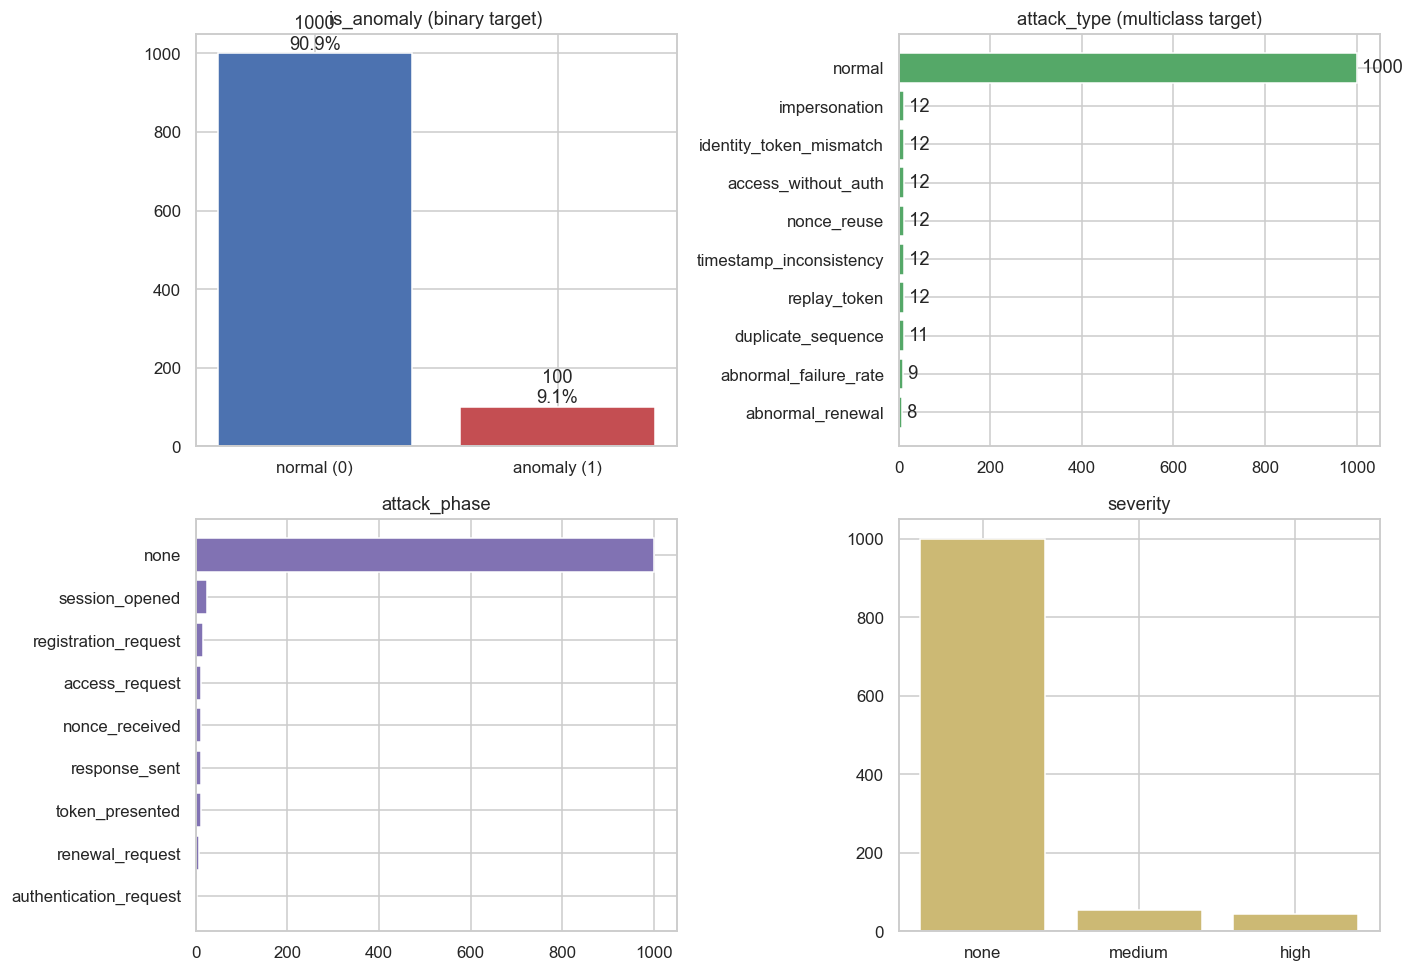

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# is_anomaly
vc = df["is_anomaly"].value_counts().sort_index()
axes[0,0].bar(["normal (0)", "anomaly (1)"], vc.values, color=["#4c72b0", "#c44e52"])
axes[0,0].set_title("is_anomaly (binary target)")
for i, v in enumerate(vc.values):
    axes[0,0].text(i, v, f"{v}\n{v/len(df)*100:.1f}%", ha="center", va="bottom")

# attack_type
at = df["attack_type"].value_counts()
axes[0,1].barh(at.index[::-1], at.values[::-1], color="#55a868")
axes[0,1].set_title("attack_type (multiclass target)")
for i, v in enumerate(at.values[::-1]):
    axes[0,1].text(v, i, f" {v}", va="center")

# attack_phase
ap = df["attack_phase"].value_counts()
axes[1,0].barh(ap.index[::-1], ap.values[::-1], color="#8172b3")
axes[1,0].set_title("attack_phase")

# severity
sv = df["severity"].value_counts()
axes[1,1].bar(sv.index, sv.values, color="#ccb974")
axes[1,1].set_title("severity")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distributions.png", bbox_inches="tight")
plt.show()

In [5]:
# Imbalance table for the multiclass target (excluding 'normal').
attack_only = df[df["attack_type"] != "normal"]["attack_type"].value_counts()
imb = pd.DataFrame({
    "n_samples": attack_only,
    "pct_of_all": (attack_only / len(df) * 100).round(2),
    "est_test_samples@20pct": (attack_only * 0.20).round(1),
})
display(Markdown("### Per-attack-class support (multiclass)"))
display(imb)

minority = int(attack_only.min())
display(Markdown(
    f"> **Imbalance warning** — rarest class has **{minority}** samples "
    f"(~**{minority*0.2:.0f}** in an 80/20 test split). Per-class recall for "
    f"such classes is statistically unstable; prefer the binary target, "
    f"stratified k-fold, or regenerate with more attacks per class."
))
imb.to_csv(OUTPUT_DIR / "multiclass_support.csv")

### Per-attack-class support (multiclass)

,n_samples,pct_of_all,est_test_samples@20pct
attack_type,,,
impersonation,12,1.09,2.4
identity_token_mismatch,12,1.09,2.4
access_without_auth,12,1.09,2.4
nonce_reuse,12,1.09,2.4
timestamp_inconsistency,12,1.09,2.4
replay_token,12,1.09,2.4
duplicate_sequence,11,1.00,2.2
abnormal_failure_rate,9,0.82,1.8
abnormal_renewal,8,0.73,1.6


> **Imbalance warning** — rarest class has **8** samples (~**2** in an 80/20 test split). Per-class recall for such classes is statistically unstable; prefer the binary target, stratified k-fold, or regenerate with more attacks per class.

## 4. Missingness

In [6]:
miss = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate":  df.isna().mean().round(4),
})
miss = miss[miss["missing_count"] > 0].sort_values("missing_rate", ascending=False)
display(miss if len(miss) else Markdown("No missing values."))
miss.to_csv(OUTPUT_DIR / "missingness.csv")

,missing_count,missing_rate
payload_hash,737,0.67


## 5. Constant, near-constant & duplicate columns/rows

Zero-variance columns add no signal; near-constant columns add almost none;
duplicate feature rows can inflate scores by leaking train rows into test.

In [7]:
nunique = df[feature_cols].nunique()
constant = nunique[nunique <= 1].index.tolist()

# Near-constant: a single value covers >99% of rows.
near_const = []
for c in feature_cols:
    top_frac = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if c not in constant and top_frac > 0.99:
        near_const.append((c, round(top_frac, 4)))

print("Constant columns      :", constant or "none")
print("Near-constant (>99%)  :")
for c, f in near_const:
    print(f"    {c:<28} dominant value covers {f*100:.1f}%")

# Duplicate rows on feature columns only (ignoring identifiers/labels).
dup_feat = df.duplicated(subset=[c for c in feature_cols], keep=False).sum()
print(f"\nDuplicate rows on feature columns: {dup_feat}")

Constant columns      : ['mqtt_version', 'topic_length', 'topic_scope_violation', 'duplicate_flag', 's1_latency_ms', 'n_registration_confirmed', 'n_token_rejected', 'n_token_expired', 'n_access_denied', 'n_timeout', 'n_disconnect']
Near-constant (>99%)  :

Duplicate rows on feature columns: 0


## 6. Key numeric feature distributions, split by class

Overlaying normal vs anomaly shows which raw signals separate the classes.

**Plotting note.** The two classes differ wildly in *spread*: for several features
the 100 anomaly sessions collapse into a near-constant spike (e.g. truncated
attacks have `mean_delay_s` ≈ 0), while the 1,000 normal sessions spread over a
wide range. With plain `density=True` that spike's bar reaches a density of ~25
and flattens the normal distribution to invisibility. To keep both classes
legible we (a) use **shared bins** clipped to the 1st–99th percentile so a single
outlier can't stretch the axis, and (b) normalize each class to a **probability**
(bars sum to 1 per class, bounded to [0, 1]) instead of density.

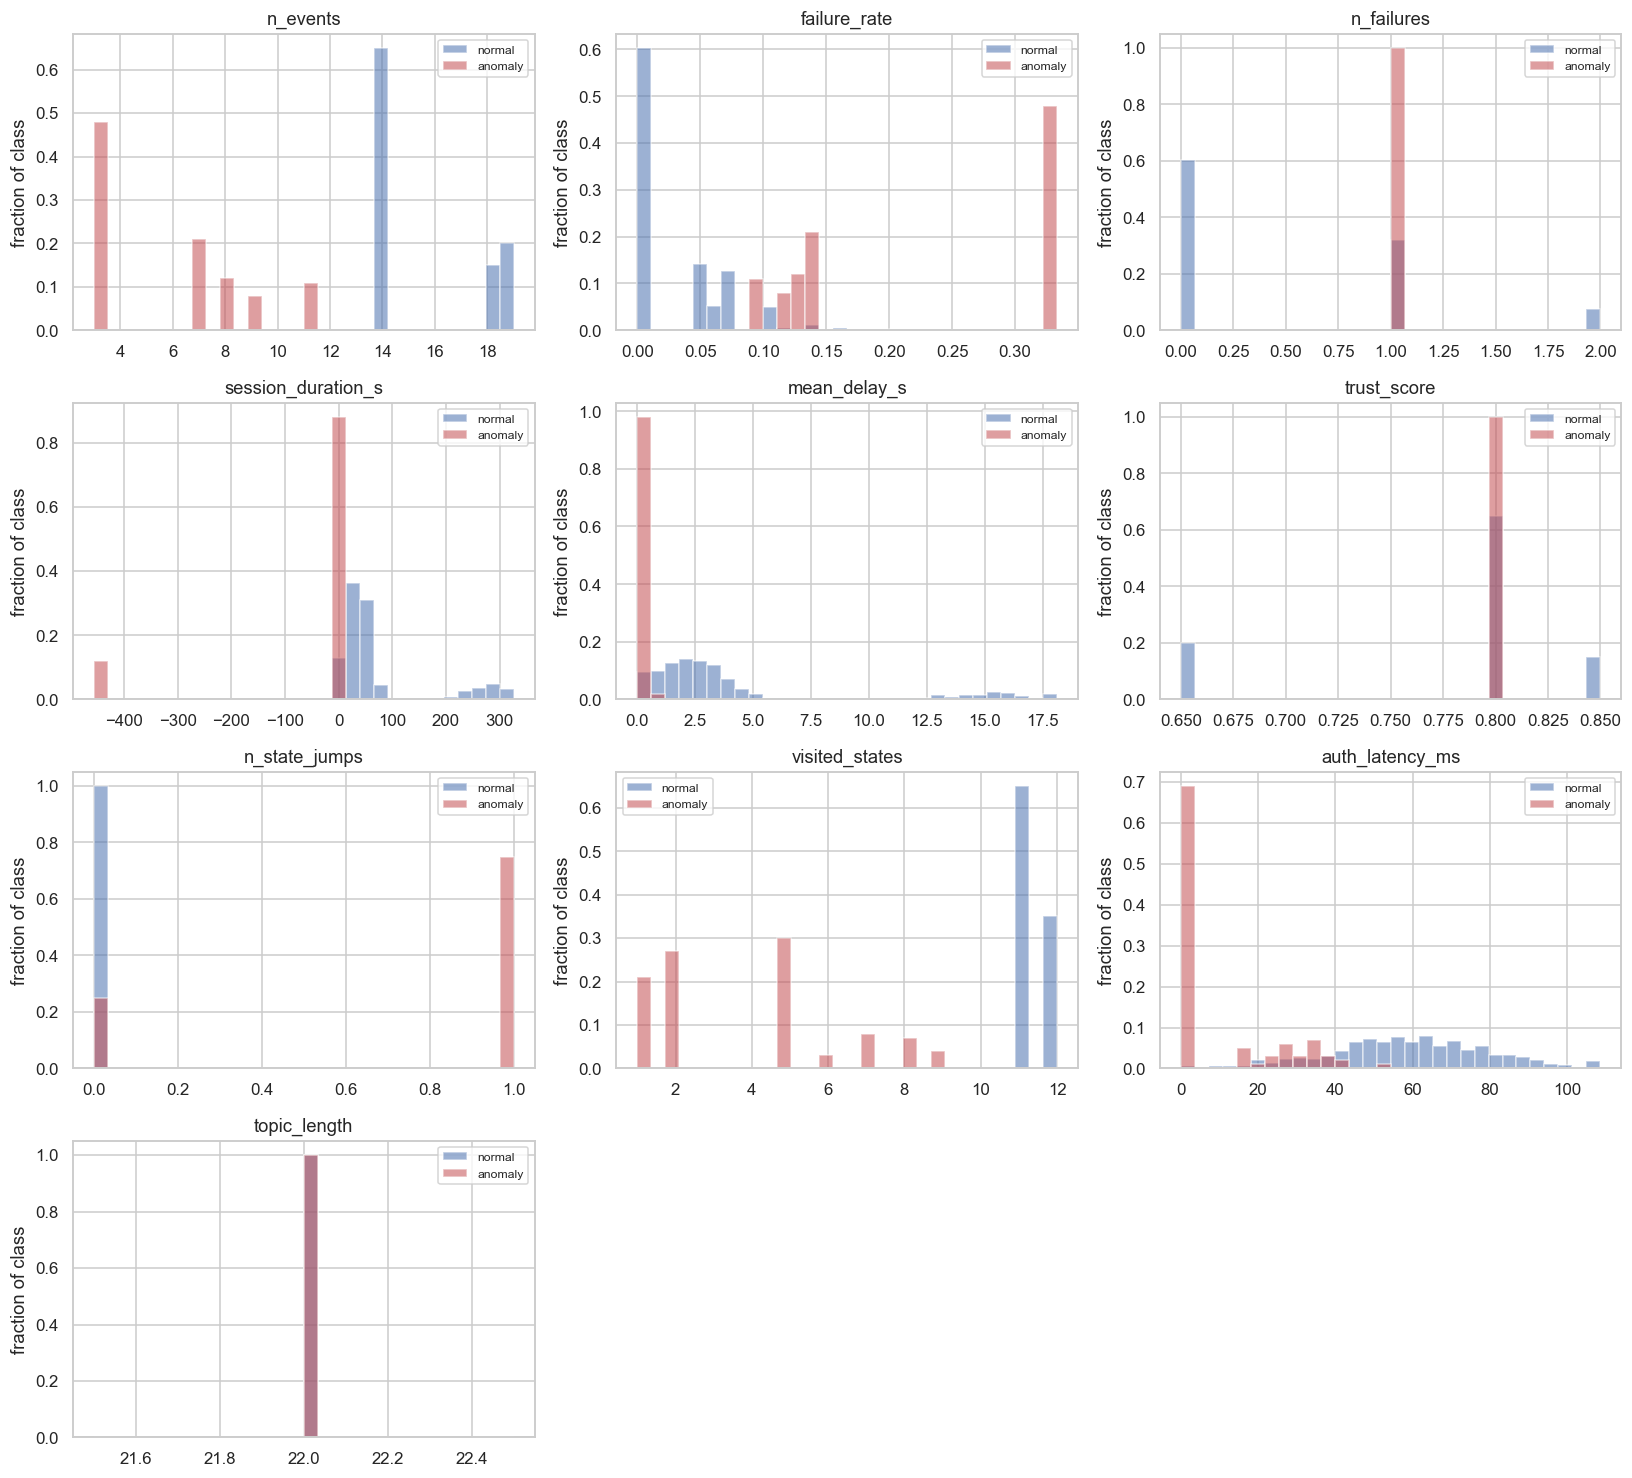

In [8]:
key_feats = [c for c in [
    "n_events", "failure_rate", "n_failures", "session_duration_s",
    "mean_delay_s", "trust_score", "n_state_jumps", "visited_states",
    "auth_latency_ms", "topic_length",
] if c in df.columns]

def hist_by_class(ax, feat, bins=30):
    s = df[feat].astype(float)
    finite = s[np.isfinite(s)]
    lo, hi = np.percentile(finite, [1, 99])      # clip outliers for the view
    if lo == hi:                                  # constant / near-constant
        lo, hi = finite.min() - 0.5, finite.max() + 0.5
    edges = np.linspace(lo, hi, bins + 1)         # shared bins across classes
    for label, color in [(0, "#4c72b0"), (1, "#c44e52")]:
        v = s[df["is_anomaly"] == label].dropna().clip(lo, hi)
        if len(v) == 0:
            continue
        ax.hist(v, bins=edges, alpha=0.55, color=color,
                weights=np.ones(len(v)) / len(v),   # -> per-class probability
                label=("normal" if label == 0 else "anomaly"))
    ax.set_title(feat)
    ax.legend(fontsize=8)

n = len(key_feats)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.4*nrow))
axes = np.atleast_1d(axes).ravel()
for ax, feat in zip(axes, key_feats):
    hist_by_class(ax, feat)
    ax.set_ylabel("fraction of class")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "numeric_by_class.png", bbox_inches="tight")
plt.show()

## 7. Data-quality flags

In [9]:
flags = {}
if "session_duration_s" in df.columns:
    flags["negative_session_duration"] = int((df["session_duration_s"] < 0).sum())
if "min_delay_s" in df.columns:
    flags["negative_min_delay"] = int((df["min_delay_s"] < 0).sum())
if "failure_rate" in df.columns:
    flags["failure_rate_out_of_[0,1]"] = int(((df["failure_rate"] < 0) | (df["failure_rate"] > 1)).sum())
if "trust_score" in df.columns:
    flags["trust_score_out_of_[0,1]"] = int(((df["trust_score"] < 0) | (df["trust_score"] > 1)).sum())

flag_df = pd.Series(flags, name="n_rows").to_frame()
display(flag_df)

# Where do negative durations land? (likely the timestamp_inconsistency attack)
if flags.get("negative_session_duration", 0):
    neg = df[df["session_duration_s"] < 0]
    display(Markdown("### attack_type of rows with negative session_duration_s"))
    display(neg["attack_type"].value_counts().to_frame("n_rows"))
flag_df.to_csv(OUTPUT_DIR / "data_quality_flags.csv")

,n_rows
negative_session_duration,12
negative_min_delay,0
"failure_rate_out_of_[0,1]",0
"trust_score_out_of_[0,1]",0


### attack_type of rows with negative session_duration_s

,n_rows
attack_type,
timestamp_inconsistency,12


## 8. Label-leakage diagnostics

For each numeric feature we measure how well a **single feature** separates
normal from anomaly using ROC-AUC (taking `max(auc, 1-auc)`). A feature that
alone reaches AUC ≈ 1.0 effectively *is* the label — keeping it makes the task
trivial and the reported scores meaningless. We also report each feature's
value among normal vs attack rows so the mechanism is visible.

In [10]:
y = df["is_anomaly"].values
rows = []
for c in numeric_cols:
    x = df[c].fillna(df[c].median())
    if x.nunique() <= 1:
        continue
    try:
        auc = roc_auc_score(y, x)
    except ValueError:
        continue
    sep = max(auc, 1 - auc)
    rows.append({
        "feature": c,
        "separability_auc": round(sep, 4),
        "mean_normal": round(df.loc[y == 0, c].mean(), 3),
        "mean_anomaly": round(df.loc[y == 1, c].mean(), 3),
        "suspected": c in SUSPECTED_LEAKAGE,
    })

leak = pd.DataFrame(rows).sort_values("separability_auc", ascending=False).reset_index(drop=True)
display(Markdown("### Top 20 single-feature separators vs `is_anomaly`"))
display(leak.head(20))
leak.to_csv(OUTPUT_DIR / "leakage_diagnostics.csv", index=False)

leaky = leak[leak["separability_auc"] >= 0.90]["feature"].tolist()
display(Markdown(
    f"> **{len(leaky)} feature(s)** individually separate the classes with "
    f"AUC ≥ 0.90 and are leakage candidates:\n>\n> `{leaky}`"
))

### Top 20 single-feature separators vs `is_anomaly`

,feature,separability_auc,mean_normal,mean_anomaly,suspected
0,pairing_result,1.0000,1.000,0.000,False
1,packet_rate,1.0000,4.993,347.000,False
2,inter_arrival_time,1.0000,228.349,3.046,False
3,visited_states,1.0000,11.350,3.910,False
4,session_present,1.0000,1.000,0.000,False
5,n_events,1.0000,15.600,5.800,False
6,s5_latency_ms,1.0000,49.444,0.000,False
7,authorization_result,1.0000,1.000,0.000,False
8,message_rate,1.0000,1.007,338.944,False
9,byte_rate,1.0000,259.344,1439511.712,False


> **30 feature(s)** individually separate the classes with AUC ≥ 0.90 and are leakage candidates:
>
> `['pairing_result', 'packet_rate', 'inter_arrival_time', 'visited_states', 'session_present', 'n_events', 's5_latency_ms', 'authorization_result', 'message_rate', 'byte_rate', 'keep_alive', 'n_session_closed', 'n_access_granted', 'reached_access_granted', 'n_token_reuses', 's4_latency_ms', 'session_duration_s', 'connection_duration', 'max_delay_s', 'mean_delay_s', 'failure_rate', 'pairing_latency_ms', 's2_latency_ms', 'reached_session_open', 'auth_latency_ms', 's3_latency_ms', 'n_token_validated', 'n_access_request', 'n_token_issued', 'n_token_presented']`

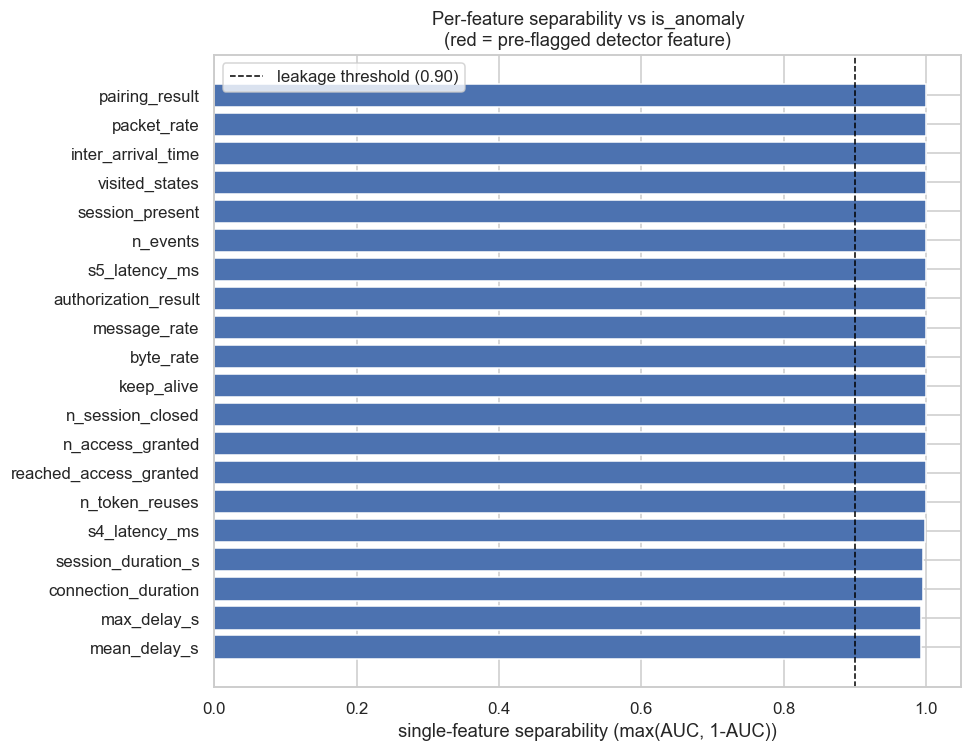

In [11]:
# Visualize the separability ranking.
top = leak.head(20).iloc[::-1]
colors = ["#c44e52" if s else "#4c72b0" for s in top["suspected"]]
plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["separability_auc"], color=colors)
plt.axvline(0.90, ls="--", color="black", lw=1, label="leakage threshold (0.90)")
plt.xlabel("single-feature separability (max(AUC, 1-AUC))")
plt.title("Per-feature separability vs is_anomaly\n(red = pre-flagged detector feature)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "leakage_ranking.png", bbox_inches="tight")
plt.show()

## 9. Mutual information with the target

Mutual information ranks features by shared information with `is_anomaly`,
capturing non-linear relationships that correlation misses. We compute it both
**with** and **without** the leakage features to show how much "honest" signal
remains in the raw features.

In [12]:
def encode(frame, cols):
    # Factorize any non-numeric column (object/string/category), then fill NaNs.
    X = frame[cols].copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = pd.factorize(X[c])[0]
    return X.fillna(X.median(numeric_only=True)).fillna(0)

usable = [c for c in feature_cols if df[c].nunique() > 1]
X_all  = encode(df, usable)
mi_all = pd.Series(
    mutual_info_classif(X_all, y, random_state=0, discrete_features="auto"),
    index=usable, name="mutual_info",
).sort_values(ascending=False)

display(Markdown("### Top 20 features by mutual information (all features)"))
display(mi_all.head(20).to_frame())

honest = [c for c in usable if c not in leaky]
X_h  = encode(df, honest)
mi_h = pd.Series(
    mutual_info_classif(X_h, y, random_state=0, discrete_features="auto"),
    index=honest, name="mutual_info",
).sort_values(ascending=False)

display(Markdown("### Top 20 features by mutual information (leakage removed)"))
display(mi_h.head(20).to_frame())
mi_all.to_frame().to_csv(OUTPUT_DIR / "mutual_info_all.csv")
mi_h.to_frame().to_csv(OUTPUT_DIR / "mutual_info_honest.csv")

### Top 20 features by mutual information (all features)

,mutual_info
pairing_result,0.305546
tcp_flags,0.305091
inter_arrival_time,0.305091
s5_latency_ms,0.305091
n_token_reuses,0.305091
reached_access_granted,0.305091
n_access_granted,0.305091
n_session_closed,0.305091
visited_states,0.305091
session_present,0.305091


### Top 20 features by mutual information (leakage removed)

,mutual_info
tcp_flags,0.305091
n_state_jumps,0.208073
n_session_opened,0.203383
n_authentication_success,0.184301
auth_result,0.182969
connack_code,0.178863
tcp_rtt,0.164974
n_nonce_reuses,0.158380
reached_authenticated,0.155746
registered_device,0.130059


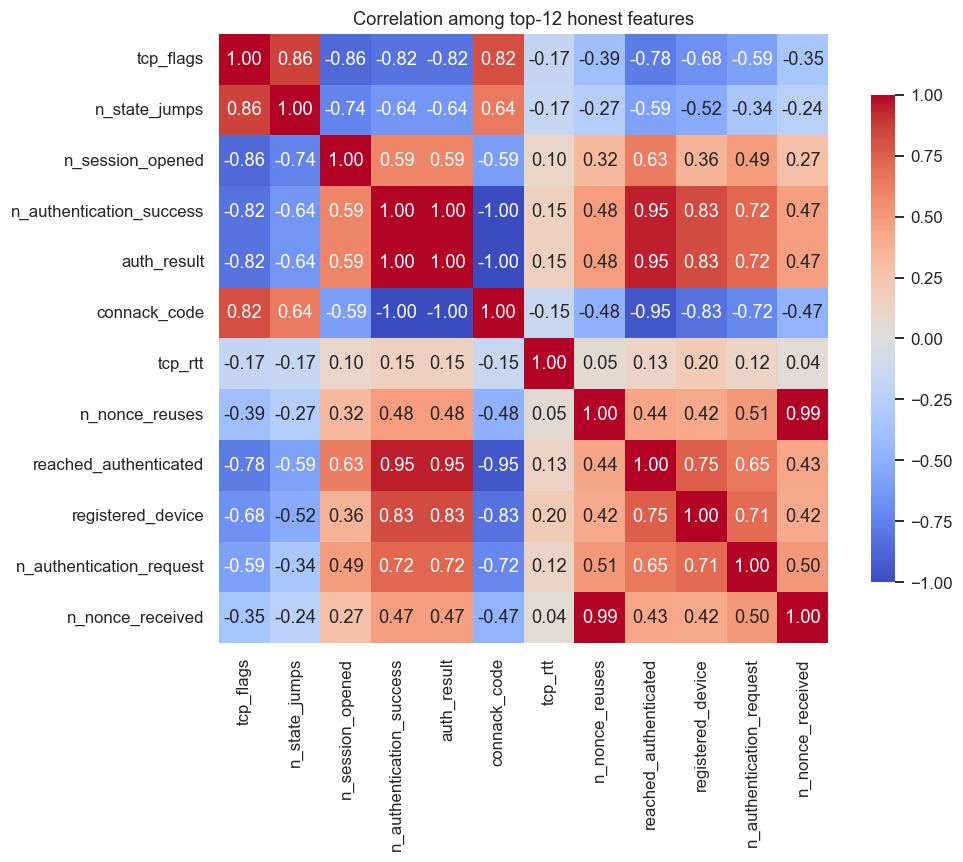

In [13]:
# Correlation heatmap among the top honest features.
top_h = mi_h.head(12).index.tolist()
corr = encode(df, top_h).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation among top-12 honest features")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 10. Per-attack-type feature signatures

z-scored mean of the most informative features per `attack_type`. Each attack
should light up a distinct set of features; rows that look identical to
`normal` would be undetectable.

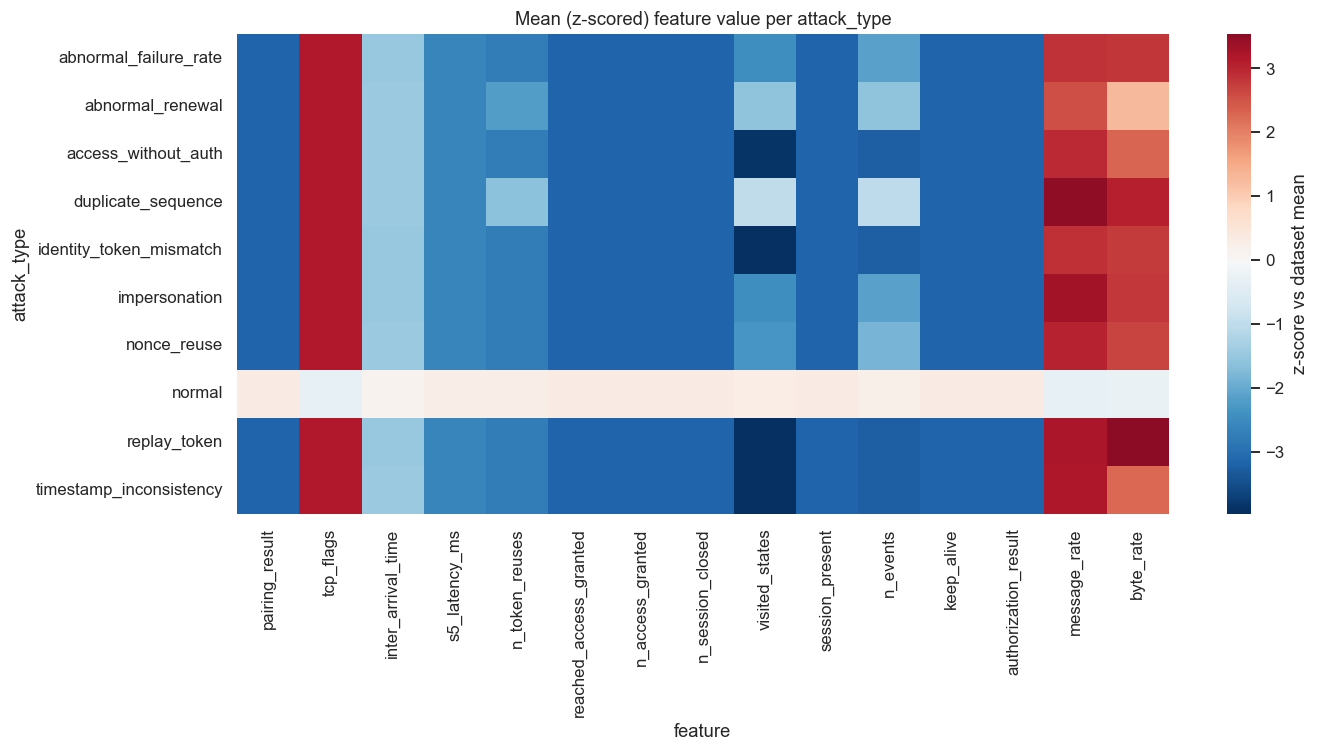

In [14]:
sig_feats = mi_all.head(15).index.tolist()
Z = encode(df, sig_feats)
Z = (Z - Z.mean()) / (Z.std() + 1e-9)
Z["attack_type"] = df["attack_type"].values
sig = Z.groupby("attack_type")[sig_feats].mean()

plt.figure(figsize=(13, 7))
sns.heatmap(sig, annot=False, cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score vs dataset mean"})
plt.title("Mean (z-scored) feature value per attack_type")
plt.xlabel("feature")
plt.ylabel("attack_type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "attack_signatures.png", bbox_inches="tight")
plt.show()
sig.to_csv(OUTPUT_DIR / "attack_signatures.csv")

## 11. Recommended feature sets & next steps

In [15]:
drop_for_ml = [c for c in IDENTIFIERS if c in df.columns]
honest_features = [c for c in feature_cols if c not in leaky and c not in drop_for_ml]

summary = {
    "sessions":                 len(df),
    "total_columns":            df.shape[1],
    "identifier_cols_dropped":  len(drop_for_ml),
    "leakage_cols_detected":    len(leaky),
    "honest_features_remaining":len(honest_features),
    "binary_minority_pct":      round(df["is_anomaly"].mean()*100, 2),
    "multiclass_min_support":   int(df[df.attack_type!='normal'].attack_type.value_counts().min()),
}
display(Markdown("### Summary"))
display(pd.Series(summary).to_frame("value"))

pd.Series(honest_features, name="honest_feature").to_csv(
    OUTPUT_DIR / "recommended_honest_features.csv", index=False)
pd.Series(leaky, name="leakage_feature").to_csv(
    OUTPUT_DIR / "leakage_features_to_drop.csv", index=False)

display(Markdown(f'''
**Recommendations**

1. **Drop identifiers** ({len(drop_for_ml)}): they uniquely tag rows and leak nothing useful.
2. **Decide on leakage features** ({len(leaky)} detected): train **with** and **without** them and
   report both — "with" shows the ceiling, "without" shows realistic detection.
3. **Prefer the binary target** for headline numbers; the multiclass minority class
   has only {summary["multiclass_min_support"]} samples — use stratified k-fold and macro-F1, or regenerate.
4. **Report attack-class recall and PR-AUC**, not just accuracy, given {summary["binary_minority_pct"]}% positives.
5. Saved artifacts: `{OUTPUT_DIR}/` (figures + CSVs).
'''))

### Summary

,value
sessions,1100.00
total_columns,103.00
identifier_cols_dropped,8.00
leakage_cols_detected,30.00
honest_features_remaining,61.00
binary_minority_pct,9.09
multiclass_min_support,8.00



**Recommendations**

1. **Drop identifiers** (8): they uniquely tag rows and leak nothing useful.
2. **Decide on leakage features** (30 detected): train **with** and **without** them and
   report both — "with" shows the ceiling, "without" shows realistic detection.
3. **Prefer the binary target** for headline numbers; the multiclass minority class
   has only 8 samples — use stratified k-fold and macro-F1, or regenerate.
4. **Report attack-class recall and PR-AUC**, not just accuracy, given 9.09% positives.
5. Saved artifacts: `feature_analysis_outputs/` (figures + CSVs).
